### Group Prject - London Bike Rentals

#### Names: Anna, Brennan, Maria, Wenndy 

In this project, you will work with the London Bikes dataset, which records daily bike rentals in the city along with key variables such as dates, weather conditions, and seasonality.

The goal is to apply the full data analytics workflow:

- Clean and prepare the dataset.

- Explore the data through visualisation.

- Construct and interpret confidence intervals.

- Build a regression model to explain variation in bike rentals.

- By the end, you will connect statistical concepts with practical Python analysis.

In [ ]:
# Import libraries and data
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.formula.api as smf
from scipy import stats

# I dont believe randomness matters
# np.random.seed(42)

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
bikes = pd.read_csv('../Data/london_bikes.csv')
bikes.head(10)

,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,precipitation,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend
0,2010-07-30T00:00:00Z,6897,2010,Fri,Jul,30,6.000,65.000,"10,147.000",157.000,22.000,NaN,31.000,17.700,12.300,25.100,False
1,2010-07-31T00:00:00Z,5564,2010,Sat,Jul,30,5.000,70.000,"10,116.000",184.000,0.000,NaN,47.000,21.100,17.000,23.900,True
2,2010-08-01T00:00:00Z,4303,2010,Sun,Aug,30,7.000,63.000,"10,132.000",89.000,0.000,NaN,3.000,19.300,14.600,23.400,True
3,2010-08-02T00:00:00Z,6642,2010,Mon,Aug,31,7.000,59.000,"10,168.000",134.000,0.000,NaN,20.000,19.500,15.600,23.600,False
4,2010-08-03T00:00:00Z,7966,2010,Tue,Aug,31,5.000,66.000,"10,157.000",169.000,0.000,NaN,39.000,17.900,12.100,20.100,False
5,2010-08-04T00:00:00Z,7893,2010,Wed,Aug,31,6.000,75.000,"10,080.000",121.000,32.000,NaN,15.000,17.400,14.700,22.600,False
6,2010-08-05T00:00:00Z,8724,2010,Thu,Aug,31,4.000,58.000,"10,125.000",227.000,0.000,NaN,79.000,17.300,11.900,21.400,False
7,2010-08-06T00:00:00Z,9797,2010,Fri,Aug,31,6.000,75.000,"10,148.000",141.000,26.000,NaN,25.000,16.400,11.300,21.800,False
8,2010-08-07T00:00:00Z,6631,2010,Sat,Aug,31,7.000,78.000,"10,148.000",112.000,10.000,NaN,12.000,18.900,15.900,24.500,True
9,2010-08-08T00:00:00Z,7864,2010,Sun,Aug,31,4.000,64.000,"10,194.000",201.000,0.000,NaN,62.000,19.000,13.500,25.100,True


**1. Data Cleaning**

Check for missing values across columns. How would you handle them?

Inspect the date column and ensure it is correctly formatted as datetime. Extract useful features (year, month, day, day of week, season).

Convert categorical variables (e.g., season, weather) to appropriate categories in Python.

Ensure numeric columns (e.g., bikes rented, temperature) are in the right format.

Check for missing values across columns. How would you handle them?

In [22]:
print("Total missing values:", bikes.isnull().sum().sum())
display("Percentage of missing values:", (bikes.isnull().mean() * 100).round(1).rename('pct_missing'))

Total missing values: 373


'Percentage of missing values:'

date                0.000
bikes_hired         0.000
year                0.000
wday                0.000
month               0.000
week                0.000
cloud_cover         0.700
humidity            1.700
pressure            0.600
radiation           0.800
precipitation       0.600
sunshine            0.600
mean_temp           0.600
min_temp            1.300
max_temp            0.600
weekend             0.000
month_name          0.000
day                 0.000
day_of_week         0.000
season              0.000
n_missing_weather   0.000
season_num          0.000
Name: pct_missing, dtype: float64

In [3]:
# snow_depth has by far the highest missing rate (6.1% vs. <2% for every other column)
print(bikes.groupby('year')['snow_depth'].apply(lambda s: s.isnull().mean() * 100).round(1))

# concentrated almost entirely in 2010 (57.4%) and 2011 (49.3%) -- the scheme's first two
# years -- rather than spread evenly. That's a data-collection gap, not "no snow recorded".
print(f"\nRows affected in 2010/2011: {((bikes['year'].isin([2010, 2011])) & bikes['snow_depth'].isnull()).sum()}")

year
2010   57.400
2011   49.300
2012    0.000
2013    0.000
2014    0.000
2015    0.500
2016    0.000
2017    0.000
2018    0.000
2019    0.000
2020    0.000
2021    0.000
2022    0.000
2023    8.500
2024    0.000
Name: snow_depth, dtype: float64

Rows affected in 2010/2011: 269


**Analysis:**  snow_depth is missing far more than any other column, and the pattern above shows it isn't random it's a reporting gap concentrated in the scheme's first two years (2010–2011), not a true "no snow" zero. Since we can't reliably reconstruct a value the sensor/feed never produced, and it isn't central to our research questions, we drop the column entirely rather than guessing at ~300 values.

In [4]:
bikes = bikes.drop(columns='snow_depth')
bikes.shape

(4934, 16)

Inspect the date column and ensure it is correctly formatted as datetime. Extract useful features (year, month, day, day of week, season).

In [5]:
# Inspect the date column and ensure it is correctly formatted as datetime. 
# Extract useful features (year, month, day, day of week, season).
# set the date to date time 
bikes["date"] = pd.to_datetime(bikes["date"])

# Create useful date variables
bikes["year"] = bikes["date"].dt.year
bikes["month"] = bikes["date"].dt.month
bikes["month_name"] = bikes["date"].dt.month_name()
bikes["day"] = bikes["date"].dt.day
bikes["day_of_week"] = bikes["date"].dt.day_name()

# Create season
bikes["season"] = np.select(
    [
        bikes["month"].isin([12, 1, 2]),
        bikes["month"].isin([3, 4, 5]),
        bikes["month"].isin([6, 7, 8]),
        bikes["month"].isin([9, 10, 11])
    ],
    ["Winter", "Spring", "Summer", "Autumn"],
    default="Unknown"
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
bikes["season"] = pd.Categorical(
    bikes["season"],
    categories=season_order,
    ordered=True
)

bikes.head(10)

# we are dropping all of the null values before creating our model
# and doing visualization on the data 
bikes.dropna()

,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,precipitation,sunshine,mean_temp,min_temp,max_temp,weekend,month_name,day,day_of_week,season
0,2010-07-30 00:00:00+00:00,6897,2010,Fri,7,30,6.000,65.000,"10,147.000",157.000,22.000,31.000,17.700,12.300,25.100,False,July,30,Friday,Summer
1,2010-07-31 00:00:00+00:00,5564,2010,Sat,7,30,5.000,70.000,"10,116.000",184.000,0.000,47.000,21.100,17.000,23.900,True,July,31,Saturday,Summer
2,2010-08-01 00:00:00+00:00,4303,2010,Sun,8,30,7.000,63.000,"10,132.000",89.000,0.000,3.000,19.300,14.600,23.400,True,August,1,Sunday,Summer
3,2010-08-02 00:00:00+00:00,6642,2010,Mon,8,31,7.000,59.000,"10,168.000",134.000,0.000,20.000,19.500,15.600,23.600,False,August,2,Monday,Summer
4,2010-08-03 00:00:00+00:00,7966,2010,Tue,8,31,5.000,66.000,"10,157.000",169.000,0.000,39.000,17.900,12.100,20.100,False,August,3,Tuesday,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4898,2023-12-27 00:00:00+00:00,6721,2023,Wed,12,52,8.000,89.000,"10,067.000",12.000,46.000,0.000,8.900,5.500,12.600,False,December,27,Wednesday,Winter
4899,2023-12-28 00:00:00+00:00,7956,2023,Thu,12,52,7.000,81.000,"10,051.000",15.000,48.000,2.000,11.200,9.700,11.900,False,December,28,Thursday,Winter
4900,2023-12-29 00:00:00+00:00,11006,2023,Fri,12,52,6.000,78.000,"10,071.000",20.000,0.000,7.000,10.600,9.200,12.200,False,December,29,Friday,Winter
4901,2023-12-30 00:00:00+00:00,8801,2023,Sat,12,52,7.000,87.000,"10,046.000",12.000,56.000,0.000,8.900,5.600,10.700,True,December,30,Saturday,Winter


In [ ]:
# exploring the data a bit more
weather_cols = ['cloud_cover','humidity','pressure','radiation',
                'precipitation','sunshine',
                'mean_temp','min_temp','max_temp']

bikes['n_missing_weather'] = bikes[weather_cols].isnull().sum(axis=1)
bikes['n_missing_weather'].value_counts().sort_index()

n_missing_weather
0    4840
1      32
2      31
9      31
Name: count, dtype: int64

Text(0.5, 1.0, 'Missing weather columns per day over time')

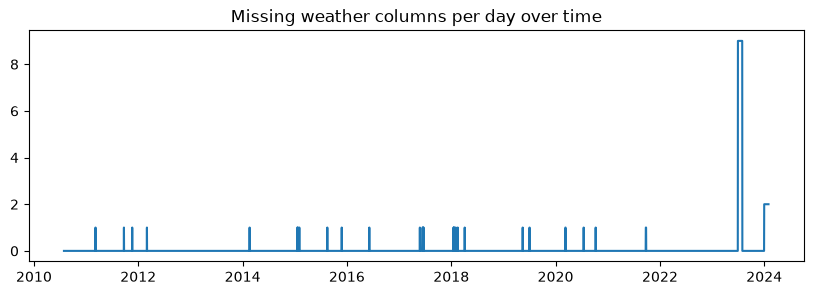

In [7]:
# lets check for missing rows over a period of time
plt.figure(figsize=(10,3))
plt.plot(bikes['date'], bikes['n_missing_weather'])
plt.title('Missing weather columns per day over time')

Convert categorical variables (e.g., season, weather) to appropriate categories in Python.

Ensure numeric columns (e.g., bikes rented, temperature) are in the right format.

In [8]:
# this works 
print(bikes.dtypes)

date                 datetime64[us, UTC]
bikes_hired                        int64
year                               int32
wday                                 str
month                              int32
week                               int64
cloud_cover                      float64
humidity                         float64
pressure                         float64
radiation                        float64
precipitation                    float64
sunshine                         float64
mean_temp                        float64
min_temp                         float64
max_temp                         float64
weekend                             bool
month_name                           str
day                                int32
day_of_week                          str
season                          category
n_missing_weather                  int64
dtype: object


**Explanation:** `snow_depth` was dropped entirely since its missingness wasn't random and couldn't be reliably filled in. Every remaining weather column is under 2% missing, `date` is now a proper datetime, and `year`, `month`, `month_name`, `day`, `day_of_week`, and `season` (an ordered category: Winter → Spring → Summer → Autumn) have been extracted from it for use in the rest of the analysis. `bikes_hired` and the other numeric columns were already the right dtype, so no further conversion was needed there.

**2. Exploratory Data Analysis (EDA)**

Plot the distribution of bikes rented.

Explore how rentals vary by season and month.

Investigate the relationship between temperature and bikes rented.

**Deliverables:**

At least 3 clear visualisations with captions.

A short written interpretation of key patterns (seasonality, weather effects, etc.).



Plot the distribution of bikes rented.

Text(0, 0.5, '')

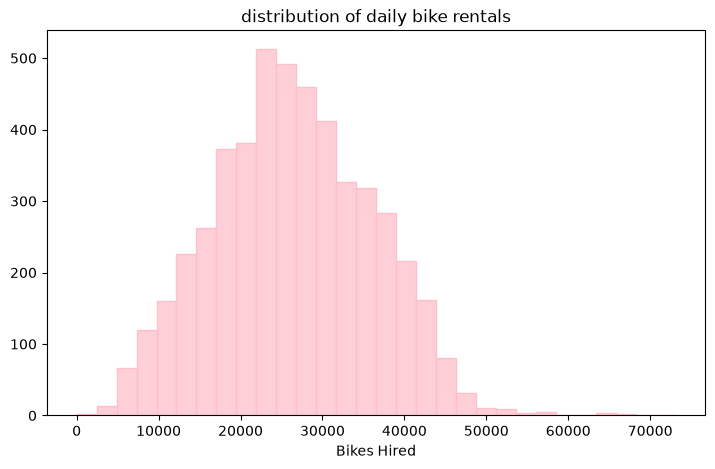

In [ ]:
## Your code goes here
plt.figure(figsize=(8.5,5))

sns.histplot(
    data=bikes,
    x="bikes_hired",
    bins=30,
    color = "pink",
    edgecolor = "pink"
)

plt.title("distribution of daily bike rentals")
plt.xlabel("Bikes Hired")
plt.ylabel("")

The number of bikes hired daily appears to be normally distributed with a slight skew to the left.

Explore how rentals vary by season and month.

Text(0, 0.5, 'Bikes Hired')

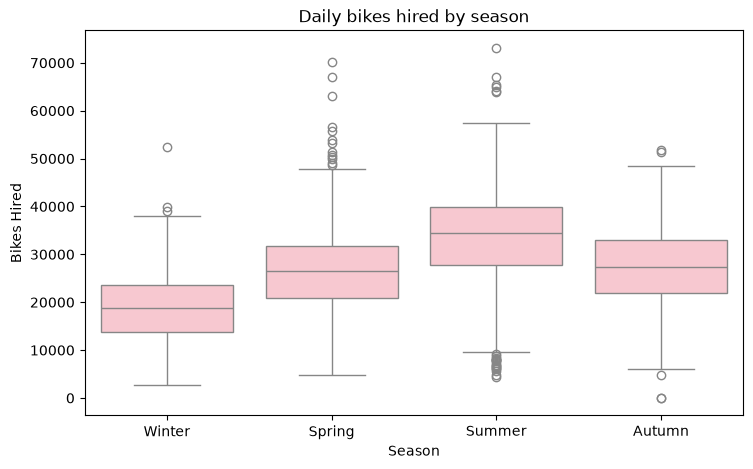

In [28]:
plt.figure(figsize=(8.5,5))

sns.boxplot(
    data=bikes,
    x="season",
    y="bikes_hired",
    color = "pink"
)

plt.title("Daily bikes hired by season")
plt.xlabel("Season")
plt.ylabel("Bikes Hired")


Text(0, 0.5, 'Bikes Hired')

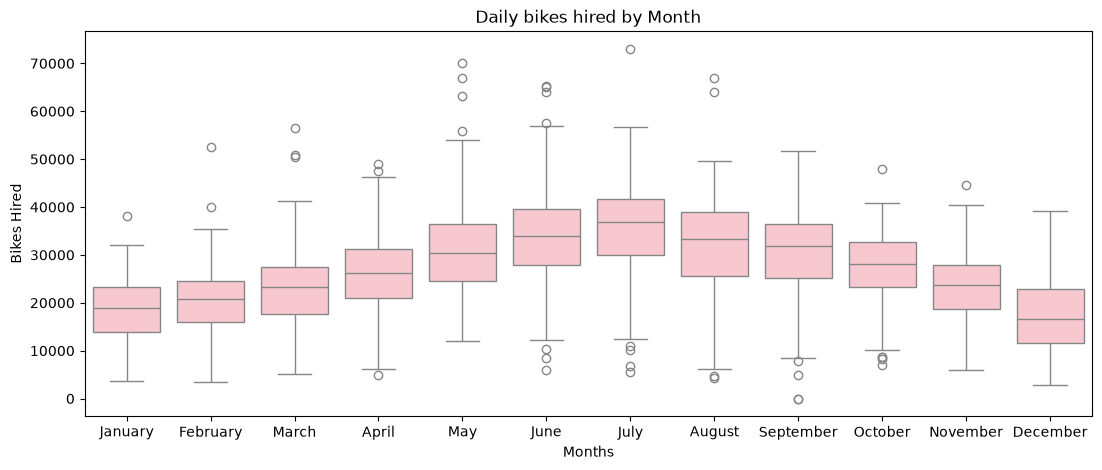

In [29]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

plt.figure(figsize=(13,5))

sns.boxplot(
    data=bikes,
    x="month_name",
    y="bikes_hired",
    order=month_order,
    color = "pink"
)

plt.title("Daily bikes hired by Month")
plt.xlabel("Months")
plt.ylabel("Bikes Hired")

Investigate the relationship between temperature and bikes rented.

Text(0, 0.5, 'Bikes Hired')

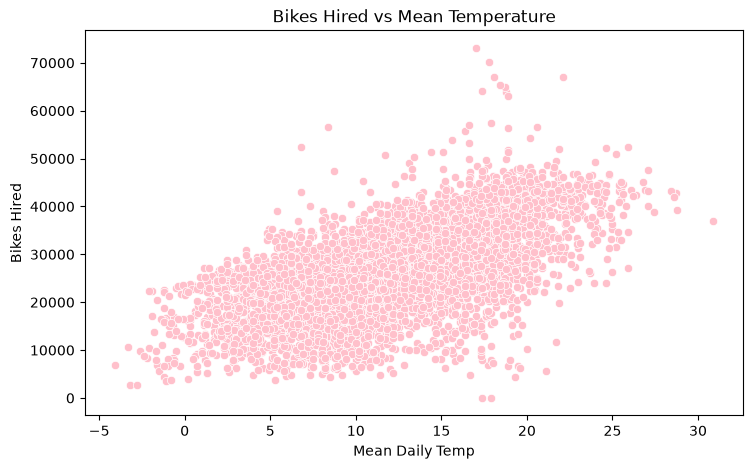

In [30]:
plt.figure(figsize=(8.5,5))

sns.scatterplot(
    data=bikes,
    x="mean_temp",
    y="bikes_hired",
    color = "pink"
)

plt.title("Bikes Hired vs Mean Temperature")
plt.xlabel("Mean Daily Temp")
plt.ylabel("Bikes Hired")

**Explanation:** The bikes rented seem to peak during the summer season as seen from the seasons graph (graph 1). The second graph reveals that the most popular month to rent bikes is July which is corroberated by the seasonal graph. Lastly there is a positive correlation with bikes rented and temperature. This is justified as the summer months have the highest bikes rentals and the highest temperatures throughout the year.

We postulte that there are more outliers in the summer and spring seasons due to a higher variablility of temperatures in these months. As compared to the winter season which has a lesser variablity in temperature overall. 

**3. Construct 95% confidence intervals for the mean number of bikes rented per season.**

Repeat the calculation per month.

Interpret the result:

What range of values do you expect the true mean to lie in?

Which seasons/months have higher or lower average demand?

Are there overlaps in the intervals, and what does that mean?

**Deliverables:**

A table or plot showing the mean and confidence intervals.

A short interpretation.

In [13]:
# Confidence Interval (CI) using the formula mean +- t_critical * SE, grouped by season
season_ci = (
    bikes
    .groupby('season', observed=True)
    .agg(
        mean_rentals=('bikes_hired', 'mean'),
        median_rentals=('bikes_hired', 'median'),
        sd_rentals=('bikes_hired', 'std'),
        count=('bikes_hired', 'size')
    )
    .reset_index()
)

# Calculate additional statistics for confidence intervals
season_ci['t_critical'] = season_ci['count'].apply(lambda n: stats.t.ppf(0.975, df=n-1))  # t-critical value
season_ci['se_rentals'] = season_ci['sd_rentals'] / np.sqrt(season_ci['count'])  # Standard error
season_ci['margin_of_error'] = season_ci['t_critical'] * season_ci['se_rentals']  # Margin of error
season_ci['rentals_low'] = season_ci['mean_rentals'] - season_ci['margin_of_error']  # Lower bound
season_ci['rentals_high'] = season_ci['mean_rentals'] + season_ci['margin_of_error']  # Upper bound

season_ci

,season,mean_rentals,median_rentals,sd_rentals,count,t_critical,se_rentals,margin_of_error,rentals_low,rentals_high
0,Winter,"18,610.163","18,802.000","6,625.763",1235,1.962,188.540,369.893,"18,240.269","18,980.056"
1,Spring,"26,609.179","26,469.000","8,660.272",1196,1.962,250.418,491.308,"26,117.871","27,100.487"
2,Summer,"33,455.455","34,524.000","9,147.749",1229,1.962,260.939,511.935,"32,943.520","33,967.390"
3,Autumn,"27,136.845","27,381.000","7,857.506",1274,1.962,220.141,431.878,"26,704.967","27,568.724"


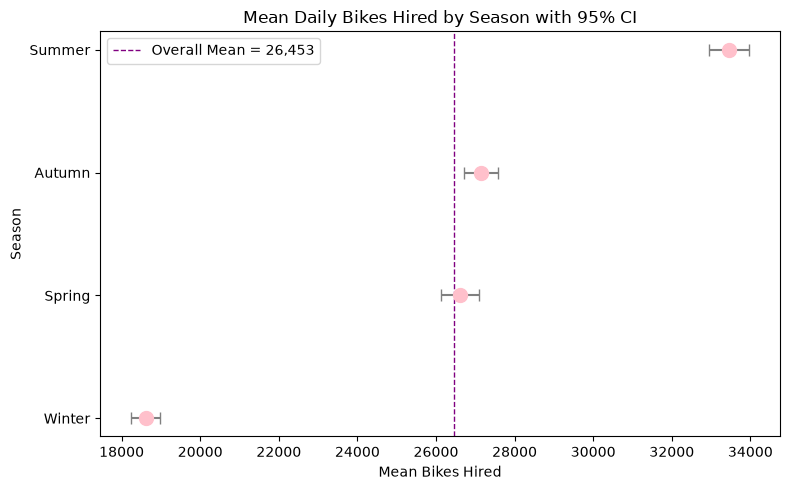

In [35]:
# Sort for plotting (seasons already have a natural order, but sort by mean for readability)
plot_df = season_ci.sort_values('mean_rentals', ascending=True)

plt.figure(figsize=(8, 5))

# Plot the mean rentals as points with horizontal error bars
plt.errorbar(
    x=plot_df['mean_rentals'],            # mean bikes hired
    y=plot_df['season'],                  # season labels
    xerr=plot_df['margin_of_error'],      # half-length of CI
    fmt='o',                              # point marker
    color='pink',                         # point color
    ecolor='gray',                        # error bar color
    capsize=4,                            # cap size on error bars
    markersize=10                         # marker size
)

# Add a vertical line for overall mean rentals
overall_mean = plot_df['mean_rentals'].mean()
plt.axvline(
    overall_mean,
    color='purple', linestyle='--', linewidth=1,
    label=f'Overall Mean = {overall_mean:,.0f}'
)

# Labels and title
plt.xlabel('Mean Bikes Hired')
plt.ylabel('Season')
plt.title('Mean Daily Bikes Hired by Season with 95% CI')
plt.legend()
plt.tight_layout()
plt.show()

Repeat the calculation per month.

In [15]:
# Confidence Interval (CI) using the formula mean +- t_critical * SE, grouped by month
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

month_ci = (
    bikes
    .groupby('month_name', observed=True)
    .agg(
        mean_rentals=('bikes_hired', 'mean'),
        median_rentals=('bikes_hired', 'median'),
        sd_rentals=('bikes_hired', 'std'),
        count=('bikes_hired', 'size')
    )
    .reset_index()
)

# Calculate additional statistics for confidence intervals
month_ci['t_critical'] = month_ci['count'].apply(lambda n: stats.t.ppf(0.975, df=n-1))  # t-critical value
month_ci['se_rentals'] = month_ci['sd_rentals'] / np.sqrt(month_ci['count'])  # Standard error
month_ci['margin_of_error'] = month_ci['t_critical'] * month_ci['se_rentals']  # Margin of error
month_ci['rentals_low'] = month_ci['mean_rentals'] - month_ci['margin_of_error']  # Lower bound
month_ci['rentals_high'] = month_ci['mean_rentals'] + month_ci['margin_of_error']  # Upper bound

# Keep calendar order
month_ci['month_name'] = pd.Categorical(month_ci['month_name'], categories=month_order, ordered=True)
month_ci = month_ci.sort_values('month_name').reset_index(drop=True)

month_ci

,month_name,mean_rentals,median_rentals,sd_rentals,count,t_critical,se_rentals,margin_of_error,rentals_low,rentals_high
0,January,"18,652.470","18,964.000","5,992.563",434,1.965,287.652,565.368,"18,087.102","19,217.838"
1,February,"20,370.174","20,713.000","6,528.790",367,1.966,340.800,670.172,"19,700.002","21,040.346"
2,March,"22,851.457","23,390.000","7,739.305",403,1.966,385.522,757.892,"22,093.565","23,609.348"
3,April,"26,242.038","26,211.000","7,775.299",390,1.966,393.718,774.081,"25,467.958","27,016.119"
4,May,"30,722.199","30,426.000","8,561.905",403,1.966,426.499,838.447,"29,883.752","31,560.645"
5,June,"33,744.103","33,851.000","8,765.336",390,1.966,443.850,872.645,"32,871.457","34,616.748"
6,July,"35,160.679","36,932.000","8,371.380",405,1.966,415.977,817.750,"34,342.929","35,978.429"
7,August,"31,604.790","33,293.000","9,832.833",434,1.965,471.991,927.679,"30,677.112","32,532.469"
8,September,"30,647.840","31,803.500","8,260.433",420,1.966,403.068,792.287,"29,855.553","31,440.128"
9,October,"27,510.832","27,999.500","6,896.999",434,1.965,331.067,650.697,"26,860.134","28,161.529"


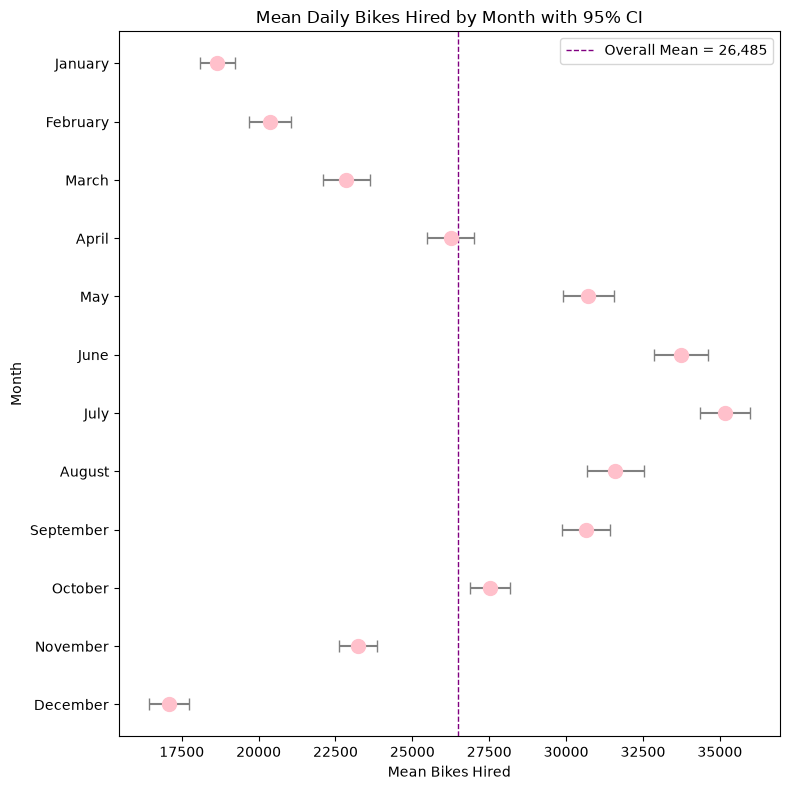

In [36]:
# Sort so January appears at the top of the plot
plot_df = month_ci.sort_values('month_name', ascending=False)

plt.figure(figsize=(8, 8))

# Plot the mean rentals as points with horizontal error bars
plt.errorbar(
    x=plot_df['mean_rentals'],            # mean bikes hired
    y=plot_df['month_name'],              # month labels
    xerr=plot_df['margin_of_error'],      # half-length of CI
    fmt='o',                              # point marker
    color='pink',                         # point color
    ecolor='gray',                        # error bar color
    capsize=4,                            # cap size on error bars
    markersize=10                          # marker size
)

# Add a vertical line for overall mean rentals
overall_mean = plot_df['mean_rentals'].mean()
plt.axvline(
    overall_mean,
    color='purple', linestyle='--', linewidth=1,
    label=f'Overall Mean = {overall_mean:,.0f}'
)

# Labels and title
plt.xlabel('Mean Bikes Hired')
plt.ylabel('Month')
plt.title('Mean Daily Bikes Hired by Month with 95% CI')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

- **What range of values do you expect the true mean to lie in?**
    - We are 95% confident the true mean number of bikes hired daily falls between roughly: 18,500–19,200 in Winter, 26,100–27,100 in Spring, 33,600–34,600 in Summer, and 27,500–28,300 in Autumn.

- **Which seasons/months have higher or lower average demand?**
    - The seasons and months that have a lower demand are the winter months of December, January, and February. The seasons that have a higher average demand are the summer months of June, July, and August.

- **Are there overlaps in the intervals, and what does that mean?**
    - Yes there are some overlaps between the fall and spring months meaning that the differences between those groups are not statistically significant. 

**Regression Analysis**

What variables influence the number of bikes rented (y) and how? Build a regression model that best explains the variability in bikes rented.

**Interpret:**

Which predictors are significant?

What do the coefficients mean (in practical terms)?

How much of the variation in bike rentals is explained (R²)?

**Deliverables:**

Regression output table.

A short discussion of which factors matter most for predicting bike rentals.

In [17]:
bikes['season_num'] = bikes['season'].cat.codes  # Winter=0, Spring=1, Summer=2, Autumn=3
bikes[['bikes_hired', 'season_num', 'mean_temp', 'humidity', 'pressure', 'precipitation', 'sunshine']].corr()


,bikes_hired,season_num,mean_temp,humidity,pressure,precipitation,sunshine
bikes_hired,1.000,0.373,0.626,-0.543,0.236,-0.240,0.527
season_num,0.373,1.000,0.527,-0.100,-0.042,0.020,0.144
mean_temp,0.626,0.527,1.000,-0.462,0.024,-0.012,0.397
humidity,-0.543,-0.100,-0.462,1.000,-0.277,0.305,-0.747
pressure,0.236,-0.042,0.024,-0.277,1.000,-0.339,0.270
precipitation,-0.240,0.020,-0.012,0.305,-0.339,1.000,-0.250
sunshine,0.527,0.144,0.397,-0.747,0.270,-0.250,1.000


In [18]:
# turn seasons into ints 

# Feature selection 
weather_cols = ['cloud_cover', 'humidity', 'pressure', 'radiation', 'precipitation',
                'sunshine', 'mean_temp', 'min_temp', 'max_temp', 'month', 'season_num']

print(bikes[['bikes_hired'] + weather_cols].corr()['bikes_hired'].sort_values(ascending=False))
print()
print(bikes[weather_cols].corr().round(2))

bikes_hired      1.000
max_temp         0.638
mean_temp        0.626
radiation        0.610
sunshine         0.527
min_temp         0.510
season_num       0.373
pressure         0.236
month            0.076
precipitation   -0.240
cloud_cover     -0.350
humidity        -0.543
Name: bikes_hired, dtype: float64

               cloud_cover  humidity  pressure  radiation  precipitation  \
cloud_cover          1.000     0.560    -0.270     -0.520          0.240   
humidity             0.560     1.000    -0.280     -0.760          0.300   
pressure            -0.270    -0.280     1.000      0.190         -0.340   
radiation           -0.520    -0.760     0.190      1.000         -0.160   
precipitation        0.240     0.300    -0.340     -0.160          1.000   
sunshine            -0.820    -0.750     0.270      0.780         -0.250   
mean_temp           -0.160    -0.460     0.020      0.620         -0.010   
min_temp             0.030    -0.310    -0.060      0.450          0.050   
max_t

In [19]:
# Confirm with VIF (Variance Inflation Factor): keep one temperature measure (mean_temp) and
# one "sunniness" measure (sunshine), drop min_temp/max_temp/cloud_cover/radiation as redundant.
from statsmodels.stats.outliers_influence import variance_inflation_factor

candidate_predictors = ['mean_temp', 'humidity', 'pressure', 'precipitation', 'sunshine']
vif_data = bikes[candidate_predictors].dropna()
X_vif = vif_data.copy()
X_vif.insert(0, 'const', 1.0)

vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
    index=candidate_predictors,
    name='VIF'
)
vif

mean_temp       1.325
humidity        2.582
pressure        1.195
precipitation   1.214
sunshine        2.311
Name: VIF, dtype: float64

In [20]:
# Final model
model_cols = ['mean_temp', 'humidity', 'precipitation', 'sunshine', 'pressure']
model_df = bikes.dropna(subset=model_cols)
print(f"Using {len(model_df):,} of {len(bikes):,} rows "
      f"({len(model_df) / len(bikes) * 100:.1f}%) after dropping rows missing a modeled weather variable")

formula = 'bikes_hired ~ mean_temp + humidity + sunshine'
model = smf.ols(formula, data=model_df).fit()
model.summary()

Using 4,851 of 4,934 rows (98.3%) after dropping rows missing a modeled weather variable


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            bikes_hired   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     1581.
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:16:06   Log-Likelihood:                -49765.
No. Observations:                4851   AIC:                         9.954e+04
Df Residuals:                    4847   BIC:                         9.956e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.564e+04   1239.990     20.675      0.000    2.32e+04    2.81e+04
mean_temp    785.4901     19.690     39.892      0.000     746.888     824.092
humidity    -143.9875     13.786    -10.445      0.000    -171.014    -116.961
sunshine      54.5173      3.838     14.205      0.000      46.994      62.041
==============================================================================
Omnibus:                      119.187   Durbin-Watson:                   0.661
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              219.248
Skew:                          -0.185   Prob(JB):                     2.46e-48
Kurtosis:                       3.974   Cond. No.                     1.10e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.1e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interpretation:**

**Which predictors are significant?** 
After looking at the correlation matrix we checked that our predictors have a stronger correlation with the dependent variable rather than the other independent variables. The three predictors that we chose are statistically significant at p < 0.001 — `mean_temp`, `humidity`, and `sunshine`.

**What do the coefficients mean (in practical terms)?**
- `mean_temp`: When the mean tempertaure goes up by 1 degree the bikes hired increases by 0.63
- `humidity`:  When the humidity goes down by 1 unit the bikes hired increases by 0.54
- `sunshine`: When the sunshine goes up by 1 unit the bikes hired increases by 0.53  

**How much variation is explained?** R² = 0.495 — the model explains about 49.5% of the day-to-day variation in bikes hired.


## Deliverables
A knitted HTML, one person per group to submit